QUESTION 1: HOUSING DATA

A: Reading the dataset

In [66]:
import pandas as pd
from IPython.display import display

# Reading the dataset
housing_data = pd.read_csv("/content/Housing.csv")
display(housing_data.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


B: Separate dependent and independent variables

In [67]:
# Y = Price (dependent), X = selected columns
Y = housing_data['price']
X = housing_data[['area', 'bedrooms', 'bathrooms', 'stories', 'furnishingstatus']]

# Convert furnishingstatus to numeric values (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)
X.head()

,area,bedrooms,bathrooms,stories,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,False,False
1,8960,4,4,4,False,False
2,9960,3,2,2,True,False
3,7500,4,2,2,False,False
4,7420,4,1,2,False,False


C Plotting each independent variable vs price

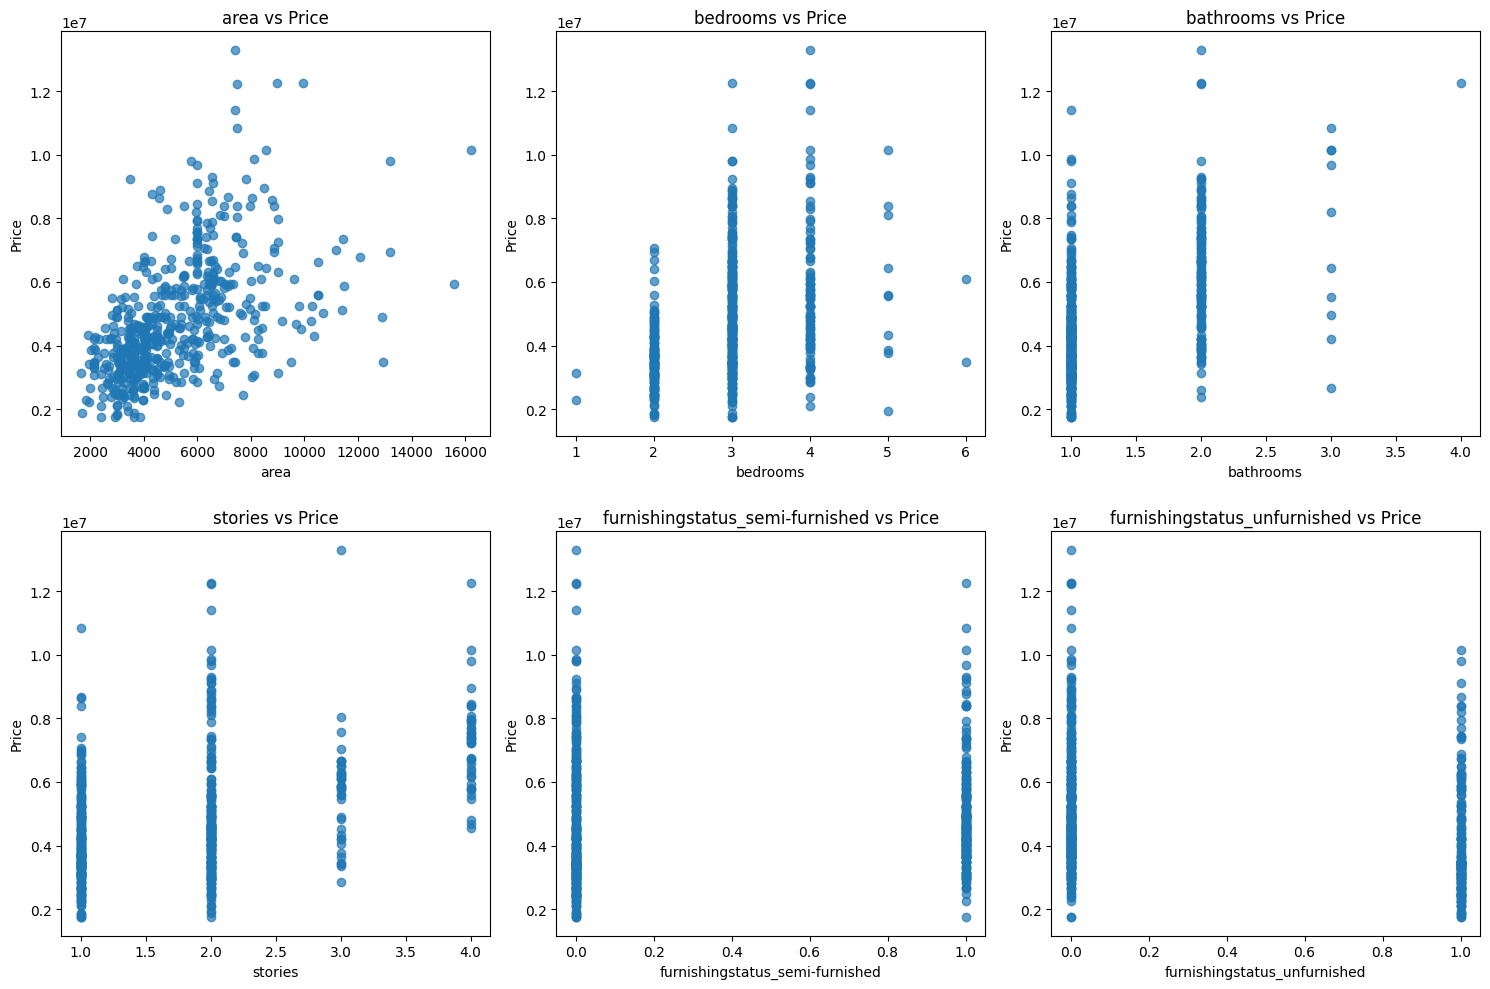

In [68]:
import matplotlib.pyplot as plt

# Create 2 rows and 3 columns (6 subplots total)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Flatten axes to make it easier to loop through
axes = axes.flatten()

# Loop through each independent variable and plot
for i, column in enumerate(X.columns):
    axes[i].scatter(X[column], Y, alpha=0.7)
    axes[i].set_title(f"{column} vs Price")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Price")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

D: Cleaning training and tests

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

E: Train Linear regression

In [70]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

F: Predict price of a specific house

In [71]:
sample_data = pd.DataFrame([[4850, 3, 3, 2, 1, 0]], columns=X.columns)

predicted_price = model.predict(sample_data)
display(f"Predicted Price: ${predicted_price[0]:,.2f}")

'Predicted Price: $6,874,863.68'

G: Predict test set and compare first 10

,Actual Price,Predicted Price
0,4060000,5.723459e+06
1,6650000,6.981713e+06
2,3710000,3.563235e+06
3,6440000,4.498499e+06
4,2800000,4.018445e+06
5,4900000,4.169860e+06
6,5250000,5.542492e+06
7,4543000,6.190353e+06
8,2450000,2.842909e+06
9,3353000,3.597326e+06


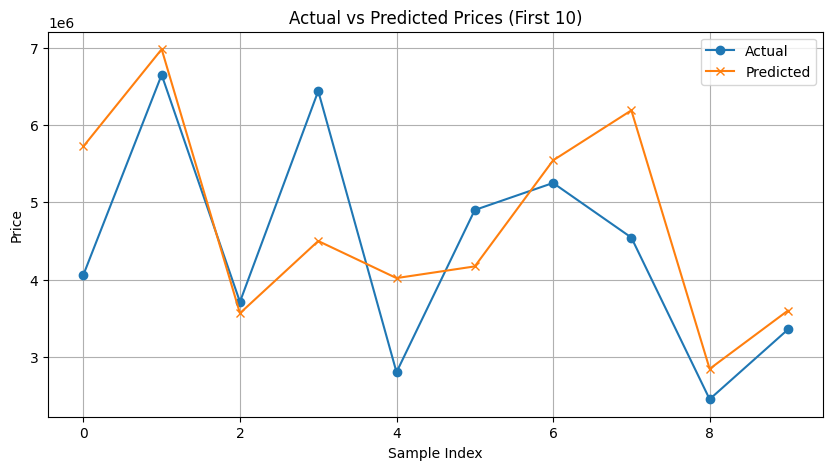

In [72]:
import numpy as np

Y_pred = model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual Price": Y_test[:10].values,
    "Predicted Price": Y_pred[:10]
})
display(comparison_df)

# Optional: Visual plot
plt.figure(figsize=(10,5))
plt.plot(np.arange(10), Y_test[:10].values, label="Actual", marker='o')
plt.plot(np.arange(10), Y_pred[:10], label="Predicted", marker='x')
plt.title("Actual vs Predicted Prices (First 10)")
plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

H: Evaluate the model

In [73]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)

display(f"R² Score: {r2:.4f}")
display(f"Mean Squared Error: {mse:,.2f}")
display(f"Root Mean Squared Error: {rmse:,.2f}")

'R² Score: 0.5302'

'Mean Squared Error: 2,374,560,756,690.51'

'Root Mean Squared Error: 1,540,960.98'

QUESTION 2: BANK DATA

A: Read data

In [74]:
bank_data = pd.read_csv("Bank.csv")
display(bank_data.info())

# Show basic statistics like mean, min, max for each column
display(bank_data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


None

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


B: Target and features

In [75]:
Y = bank_data['Personal Loan']
X = bank_data[['Age', 'Experience', 'Income', 'Education']]

# Show the first few rows to make sure it's correct
display(X.head())

,Age,Experience,Income,Education
0,25,1,49,1
1,45,19,34,1
2,39,15,11,1
3,35,9,100,2
4,35,8,45,2


C: Standard Scaling

In [76]:
from sklearn.preprocessing import StandardScaler

# Create the scaler object
scaler = StandardScaler()
# Fit and transform X to scale all features
X_scaled = scaler.fit_transform(X)

D: Split to train and test

In [77]:
from sklearn.model_selection import train_test_split


# Using 80% for training and 20% for testing
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

E: Training logistic regression

In [78]:
from sklearn.linear_model import LogisticRegression


# Creating and training the model
log_model = LogisticRegression()
log_model.fit(X_train, Y_train)

LogisticRegression()

F: Confusing matrix

In [79]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

Y_pred = log_model.predict(X_test)

# Calculate accuracy and F1 score
display(f"Accuracy: {accuracy_score(Y_test, Y_pred):.4f}")
display(f"F1 Score: {f1_score(Y_test, Y_pred):.4f}")
display(pd.DataFrame(confusion_matrix(Y_test, Y_pred),
                     columns=["Predicted: No", "Predicted: Yes"],
                     index=["Actual: No", "Actual: Yes"]))

'Accuracy: 0.9500'

'F1 Score: 0.7126'

,Predicted: No,Predicted: Yes
Actual: No,888,7
Actual: Yes,43,62


G: Cross Validation

In [80]:
from sklearn.model_selection import cross_val_score


# Run cross validation with 5 folds using accuracy as the scoring metric
cv_scores = cross_val_score(log_model, X_scaled, Y, cv=5, scoring='accuracy')
display(f"5-Fold Accuracy Scores: {cv_scores}")
display(f"Average Accuracy: {cv_scores.mean():.4f}")

'5-Fold Accuracy Scores: [0.949 0.931 0.948 0.94  0.94 ]'

'Average Accuracy: 0.9416'

H: 5 new customers prediction

In [81]:
# New customer info: [Age, Experience, Income, Education]
new_customers = [
    [40, 10, 80, 3],
    [30, 5, 60, 2],
    [55, 30, 150, 3],
    [25, 2, 40, 1],
    [45, 20, 120, 3]
]

new_customers_scaled = scaler.transform(new_customers)

# Predict personal loan acceptance
new_predictions = log_model.predict(new_customers_scaled)
prediction = pd.DataFrame(new_customers, columns=['Age', 'Experience', 'Income', 'Education'])
prediction['Predicted Loan? (1 = Yes, 0 = No)'] = new_predictions

display(prediction)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Age,Experience,Income,Education,"Predicted Loan? (1 = Yes, 0 = No)"
0,40,10,80,3,0
1,30,5,60,2,0
2,55,30,150,3,1
3,25,2,40,1,0
4,45,20,120,3,1
